# **Complete repository step-by-step diagnostics. (Simulation Modules)**

Speed values in this repo are km/h, and one simulation tick equals one second.

In [ ]:
from typing import Any, Callable, Optional
from IPython.display import Image
from rich import print 

def assert_true(condition: bool, message: str) -> bool:
    if not condition: raise AssertionError(message)
    return True

def validate_call(label: str, expected_valid: bool, func: Callable, *args: Any, **kwargs: Any) -> Optional[Any]:
    try:
        result = func(*args, **kwargs)
    except Exception as exc:
        if expected_valid:
            print(f"[bold red][EXCEPTION] {label}: Expected success but crashed with {type(exc).__name__}({exc})[/bold red]")
        else:
            print(f"[bold cyan][REJECTED] {label}: Safely blocked with {type(exc).__name__}({exc})[/bold cyan]")
        return None
    else:
        if expected_valid:
            print(f"[bold green][VALIDATED] {label}: Executed successfully.[/bold green]")
            return result
        print(f"[bold magenta][FALSE POSITIVE] {label}: Expected rejection but execution succeeded.[/bold magenta]")
        return result


In [1]:
import os
import json
import hashlib
import yaml
from dotenv import load_dotenv
from utils.city_graph import CityGraph
from utils.direct_demand_sampler import DirectDemandSampler, DDMConfig
from utils.route import RouteGenerator, route_from_coords
from utils.travel_graph import TravelGraph

load_dotenv()
TOMTOM_API_KEY = os.getenv("TOMTOM_API_KEY")

with open('configs/iligan_configs.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

USE_CACHE = True
CACHE_DIR = cfg["global"]["cache_dir"]
os.makedirs(CACHE_DIR, exist_ok=True)

_cache_key_str = str(cfg["city_graph"]) + str(cfg["ddm"]) + str(cfg["travel_graph"])
_cache_hash = hashlib.md5(_cache_key_str.encode()).hexdigest()
ROUTES_CACHE_PATH = os.path.join(CACHE_DIR, f"{_cache_hash}_routes.json")

print("[SIM SETUP] Initializing base models...")

city_graph_cfg = cfg["city_graph"]
city = CityGraph(
    bbox=tuple(city_graph_cfg["bbox"]),
    name=city_graph_cfg["name"],
    landmarks=city_graph_cfg.get("landmarks"),
    pbf_path=city_graph_cfg["pbf_path"],
    use_api=False,
    verbose=True,
    cache_dir=CACHE_DIR,
    cache_prefix=city_graph_cfg["cache_prefix"]
)

ddm_params = cfg["ddm"].copy()
ddm_params["cache_dir"] = CACHE_DIR

sampler = DirectDemandSampler(
    city=city,
    config=DDMConfig(**ddm_params),
    verbose=True
)

if USE_CACHE and os.path.exists(ROUTES_CACHE_PATH):
    print(f"[SIM SETUP] Loading deterministic routes from {ROUTES_CACHE_PATH}")
    with open(ROUTES_CACHE_PATH, "r") as f:
        routes_data = json.load(f)
        
    routes = [route_from_coords(city, json.dumps(coords)) for coords in routes_data]
    
    tg = TravelGraph(
        cg=city,
        config=cfg["travel_graph"],
        routes=routes
    )
    print("[SIM SETUP] Simulation stack loaded successfully.")
else:
    print("[SIM SETUP] Generating stochastic routes and building TravelGraph...")
    generator = RouteGenerator(
        city_graph=city,
        sampler=sampler,
        verbose=True
    )
    
    tg = TravelGraph(
        cg=city,
        route_generator=generator,
        config=cfg["travel_graph"],
        n_routes=20,
        n_points=5,
    )

    routes_data = [[(e.start.lat, e.start.lon) for e in r.path] for r in tg.routes]
    with open(ROUTES_CACHE_PATH, "w") as f:
        json.dump(routes_data, f)
        
    print(f"[SIM SETUP] Routes cached locally at {ROUTES_CACHE_PATH}")

[SIM SETUP] Initializing base models...
[CITY GRAPH] Loading graph from binary cache.


KeyboardInterrupt: 

## **Jeep System** (in jeep.py and jeep_system.py)

[VALIDATED] Generate demo route: Executed successfully.

[VALIDATED] Spawn jeep on route: Executed successfully.

Target node count for full loop: 1774

Successfully traversed all 1774 nodes in 3539 ticks.

[VALIDATED] Compile single jeep loop GIF: Executed successfully.

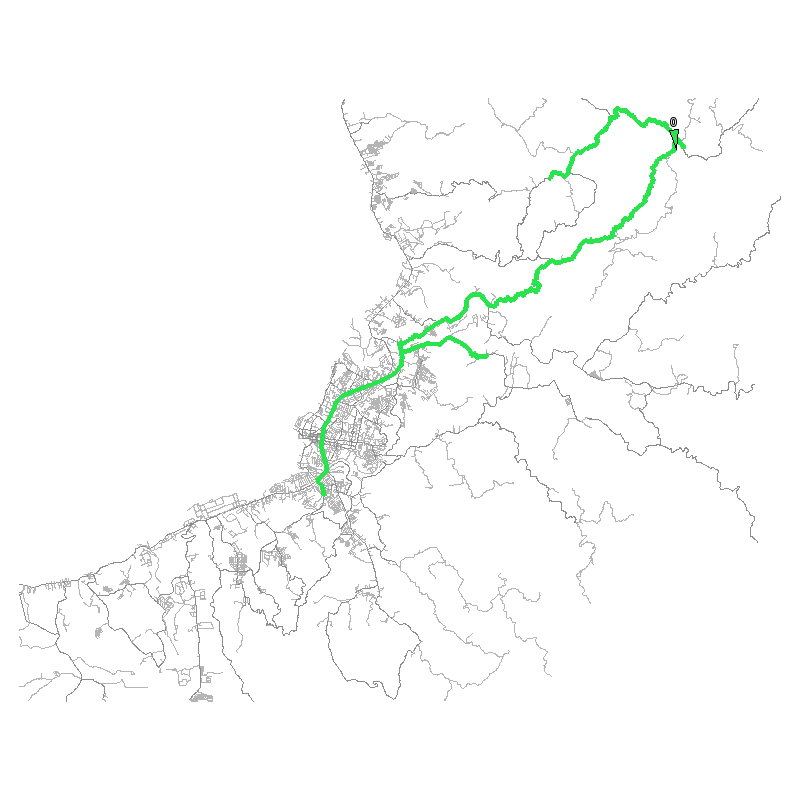

In [ ]:
# Single Jeep Traversal & Visualization

from utils.jeep import Jeep
from utils.visualization import compile_to_gif
from IPython.display import Image as IPyImage, display
from PIL import Image

# 1. Generate Route & Initialize Jeep
demo_route = validate_call(
    "Generate demo route",
    True,
    generator.generate,
    n_points=5
)

start_node = demo_route.path[0].start
jeep = validate_call(
    "Spawn jeep on route",
    True,
    Jeep,
    demo_route,
    (start_node.lon, start_node.lat),
    60.0 # 60 km/h
)

# 2. Track Expected Nodes
expected_node_ids = {edge.start.id for edge in demo_route.path}
traversed_node_ids = set()
print(f"Target node count for full loop: {len(expected_node_ids)}")

# 3. Simulate and Render
context = city.get_bounds()
frames = []
tick = 0
base_map = city.draw(size=800)

while True:
    jeep.update()
    tick += 1
    
    # Track node traversal
    passed_nodes = jeep.nodes_passed_this_frame() or []
    for node, _ in passed_nodes:
        traversed_node_ids.add(node.id)
        
    # Render frame
    if tick % 30 == 0:
        frame = demo_route.draw(context, base_map.copy(), width=4)
        frame = jeep.draw(context, frame, radius=12)
        frames.append(frame)

    # Break condition: All required nodes have been traversed in one loop
    if traversed_node_ids == expected_node_ids:
        print(f"Successfully traversed all {len(expected_node_ids)} nodes in {tick} ticks.")
        break
    
    # Failsafe
    if tick > 10000: # ~2.7 hours of simulation time at 1 tick/sec
        print("[REJECTED] Jeep failed to complete loop within an hour of simulation time.")
        break

gif_bytes = validate_call(
    "Compile single jeep loop GIF",
    True,
    compile_to_gif,
    frames,
    6,
    export_to="utils/.cache/jeep_route_loop.gif"
)
if gif_bytes:
    display(IPyImage(data=gif_bytes, format="gif"))

[VALIDATED] Initialize JeepSystem: Executed successfully.

Running JeepSystem simulation for 300 ticks...

Simulation capped at 300 ticks.

[VALIDATED] Compile JeepSystem GIF: Executed successfully.

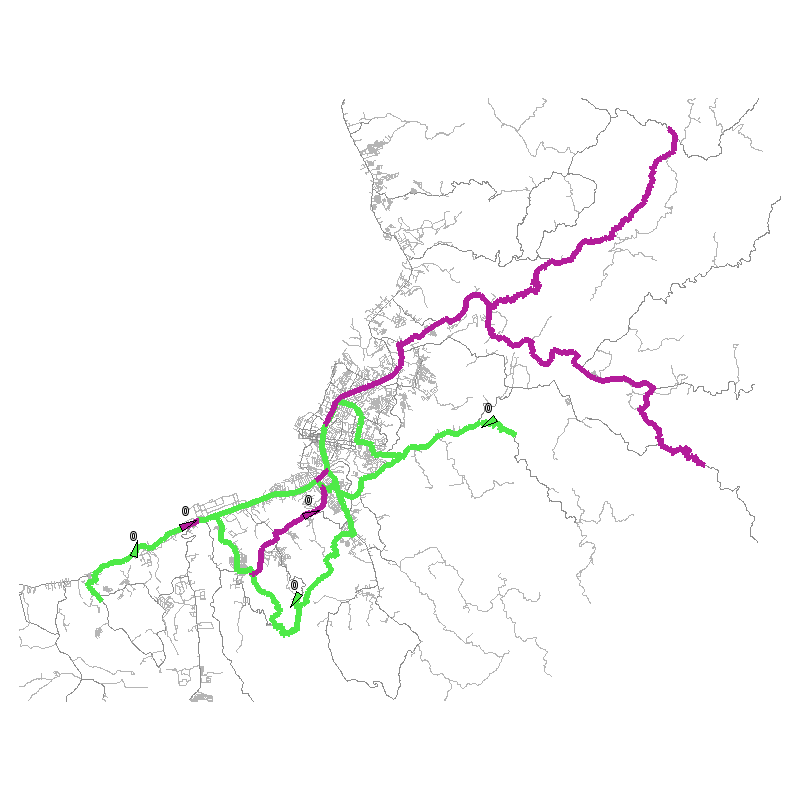

In [ ]:
# Jeep System Multi-Route Simulation

from utils.jeep_system import JeepSystem
from utils.route import RouteSystem
from IPython.display import Image as IPyImage, display

# 1. Setup Multiple Routes
rs = RouteSystem()
route_A = generator.generate(n_points=4)
route_B = generator.generate(n_points=5)
rs.add_route(route_A)
rs.add_route(route_B)

# 2. Spawn Fleet
fleet = []
# 3 Jeeps on Route A
for _ in range(3):
    start = route_A.path[0].start
    fleet.append(Jeep(route_A, (start.lon, start.lat), speed=45.0))

# 2 Jeeps on Route B
for _ in range(2):
    start = route_B.path[0].start
    fleet.append(Jeep(route_B, (start.lon, start.lat), speed=50.0))

system = validate_call(
    "Initialize JeepSystem",
    True,
    JeepSystem,
    jeeps=fleet,
    routes=[route_A, route_B],
    weight_tolerance=50.0
)

# 3. Simulate with Tick Cap
system_frames = []
TICK_CAP = 300

# Fix applied here: Enforce exact method signatures and context extraction.
context = city.get_bounds()
base_map = city.draw(size=800)

# Pre-draw routes onto the base map using RouteSystem's dashed renderer
base_map = rs.draw(context, base_map, line_width=6, dash_length=15)

print(f"Running JeepSystem simulation for {TICK_CAP} ticks...")

for tick in range(TICK_CAP):
    system.update()
    
    if tick % 5 == 0:
        frame = base_map.copy()
        frame = system.draw(context, frame, radius=10)
        system_frames.append(frame)

print(f"Simulation capped at {TICK_CAP} ticks.")

sys_gif_bytes = validate_call(
    "Compile JeepSystem GIF",
    True,
    compile_to_gif,
    system_frames,
    10,
    export_to="utils/.cache/jeep_system_demo.gif"
)
if sys_gif_bytes:
    display(IPyImage(data=sys_gif_bytes, format="gif"))

## **Passenger Generator** (in passenger.py and passenger_generator.py)

In [ ]:
from utils.passenger import Passenger
from IPython.display import Image as IPyImage, display

# 1. Acquire a valid full journey from the Travel Graph
origin = sampler.get_point()
dest = sampler.get_point()

journey = None
while not journey:
    origin = sampler.get_point()
    dest = sampler.get_point()
    journey = tg.findShortestJourney(origin, dest)

print(f"Target journey length: {len(journey)} edges")

test_passenger = validate_call(
    "Initialize Passenger",
    True,
    Passenger,
    start_pos=(origin.lon, origin.lat),
    journey=journey,
    speed=5.0
)

# 2. Stateful Mock Jeep
class MockJeep:
    def __init__(self, pos):
        self.curr_pos = pos

# 3. Simulate Lifecycle
tick = 0
state_history = []
ride_ticks = 0
target_node = None

while test_passenger.state != "DONE":
    test_passenger.update()
    tick += 1
    
    # Track state changes
    if not state_history or state_history[-1] != test_passenger.state:
        state_history.append(test_passenger.state)
        
        current_edge_id = "N/A"
        if test_passenger._edge_idx < len(test_passenger.journey):
            current_edge_id = test_passenger.journey[test_passenger._edge_idx].id
            
        print(f"[Tick {tick:03d}] State: {test_passenger.state:<8} | Active Edge: {current_edge_id}")
    
    # Boarding Intervention
    if test_passenger.state == "WAITING" and test_passenger.wait_ticks > 5:
        target_node = test_passenger.get_target_alight_node()
        mock_jeep = MockJeep((test_passenger.curr_lon, test_passenger.curr_lat))
        test_passenger.current_jeep = mock_jeep
        test_passenger.state = "RIDING"
        test_passenger.wait_ticks = 0
        ride_ticks = 0
        
    # Riding Intervention
    elif test_passenger.state == "RIDING":
        ride_ticks += 1
        if ride_ticks > 5:  # Force ride to persist for 5 ticks
            if target_node:
                test_passenger.current_jeep.curr_pos = (target_node.lon, target_node.lat)
                test_passenger.curr_lat = target_node.lat
                test_passenger.curr_lon = target_node.lon
                
            test_passenger.complete_ride()
            test_passenger.current_jeep = None
            test_passenger.state = "WALKING"
        
    if tick > 7200:
        print("[REJECTED] Passenger failed to complete journey within 2 simulated hours.")
        break

validate_call(
    "Passenger lifecycle sequence validation",
    True,
    assert_true,
    "DONE" in state_history,
    "Passenger did not reach the DONE state."
)

Target journey length: 946 edges

[VALIDATED] Initialize Passenger: Executed successfully.

[Tick 001] State: WALKING  | Active Edge: SW51058

[Tick 122] State: WAITING  | Active Edge: RI_R0_01404

[Tick 129] State: RIDING   | Active Edge: RI_R0_01404

[Tick 135] State: DONE     | Active Edge: N/A

[VALIDATED] Passenger lifecycle sequence validation: Executed successfully.

True

In [ ]:
# Passenger Generator & System Load Visualization

from utils.passenger_generator import PassengerGenerator

# 1. Initialize Generator
# rate_per_hour: Expected passengers every hour.
pg = validate_call(
    "Initialize PassengerGenerator",
    True,
    PassengerGenerator,
    tg=tg,
    sampler=sampler,
    rate_per_hour=40.0, 
    stdev=5.0,
    speed=5.0
)

# 2. Simulation Setup
SIMULATION_TICKS = 400
pg_frames = []

context = city.get_bounds()
base_map = city.draw(size=800)

print(f"Running PassengerGenerator simulation for {SIMULATION_TICKS} ticks...")

for tick in range(SIMULATION_TICKS):
    for i in range(20): # Speed up simulation 20x by updating 20 times per tick
        pg.update()
    
    # Render every 5th frame to maintain a smooth, lightweight GIF
    if tick % 5 == 0:
        frame = base_map.copy()
        
        # Draw all active passengers
        for p in pg.passengers:
            frame = p.draw(context, frame, size=6)
            
        pg_frames.append(frame)

print(f"Simulation complete. Metric summary:")
print(f" - Currently Active: {len(pg.passengers)}")
print(f" - Successfully Archived (DONE): {len(pg.archived_passengers)}")
print(f" - Total Generated: {len(pg.get_all_generated_journeys())}")

pg_gif_bytes = validate_call(
    "Compile PassengerGenerator GIF",
    True,
    compile_to_gif,
    pg_frames,
    8,
    export_to="utils/.cache/passenger_generator_demo.gif"
)
if pg_gif_bytes:
    display(IPyImage(data=pg_gif_bytes, format="gif"))

[VALIDATED] Initialize PassengerGenerator: Executed successfully.

Running PassengerGenerator simulation for 400 ticks...

KeyboardInterrupt: 